In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

In [141]:
df = pd.read_csv("Dataset/student-mat.csv",sep=";")
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [104]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [105]:
df.shape

(395, 33)

In [106]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [107]:
df.isnull().sum().sum()

np.int64(0)

In [108]:
corr = df.corr(numeric_only=True)
corr["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

In [146]:
Features = ["studytime", "failures", "absences", "G1", "G2"]
X = df[Features]
y = df["G3"]

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [149]:
prediction = model.predict(X_test)
mae = mean_absolute_error(y_test, prediction)
r2 = r2_score(y_test, prediction)

In [150]:
print(mae)
print(r2)

1.339415908267094
0.7821754247320556


In [115]:
rmodel = RandomForestRegressor(n_estimators=100, random_state=42)
rmodel.fit(X_train, y_train)
predict = rmodel.predict(X_test)

In [116]:
mae_r = mean_absolute_error(y_test, predict)
r2_r = r2_score(y_test, predict)

In [117]:
print(mae_r)
print(r2_r)

1.0525179827205144
0.8725239455080609


In [118]:
print("___Linear Regression___")
print("MAE:",mae)
print("R2:",r2)

print("\n____Random Forest____")
print("MAE:",mae_r)
print("R2:",r2_r)

___Linear Regression___
MAE: 1.339415908267094
R2: 0.7821754247320556

____Random Forest____
MAE: 1.0525179827205144
R2: 0.8725239455080609


In [119]:
finalprediction = rmodel.predict(X_test)
df_compare = pd.DataFrame({
    "Actual":y_test,
    "Predicted":finalprediction
})
df_compare.head()

,Actual,Predicted
78,10,8.35
371,12,11.49
248,5,6.77
55,10,9.48
390,9,9.20


In [120]:
error = abs(y_test.values - finalprediction)
print("Average Error:",np.mean(error))

Average Error: 1.0525179827205144


In [121]:
student = pd.DataFrame([[3, 0, 4, 14, 15]],
                       columns=["studytime", "failures", "absences", "G1", "G2"])
predi = rmodel.predict(student)
print("Predicted Final Score:",predi)

Predicted Final Score: [15.89]


In [122]:
importance = rmodel.feature_importances_
for i in range(len(Features)):
    print(Features[i], ":", importance[i])

studytime : 0.020380953222018595
failures : 0.014807402660702311
absences : 0.11913971741799659
G1 : 0.03181848251619761
G2 : 0.8138534441830849


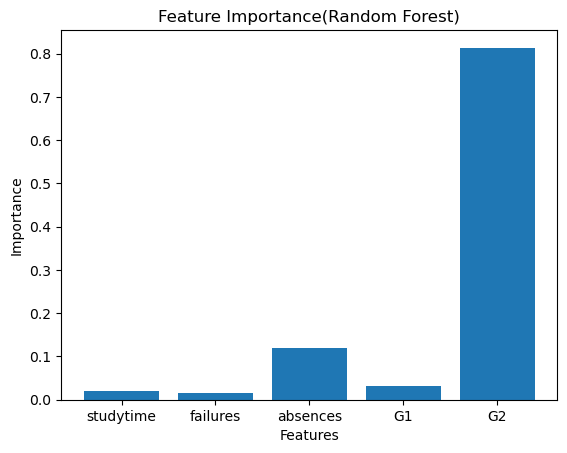

In [123]:
plt.bar(Features, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance(Random Forest)")
plt.show()

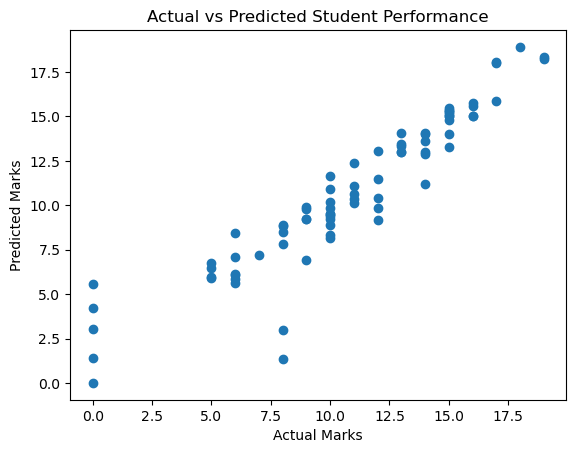

In [124]:
plt.scatter(y_test, finalprediction)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Student Performance")
plt.show()

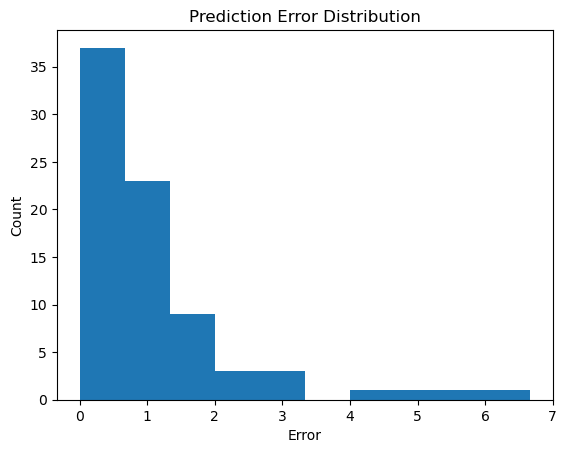

In [125]:
plt.hist(error)
plt.xlabel("Error")
plt.ylabel("Count")
plt.title("Prediction Error Distribution")
plt.show()

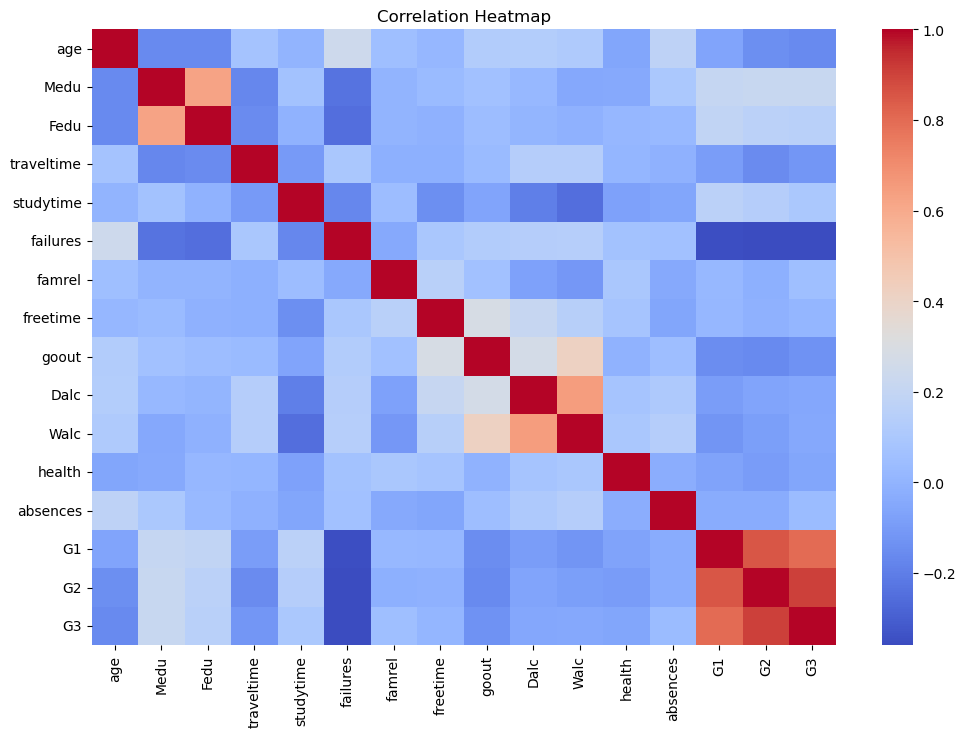

In [130]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [131]:
Scores = cross_val_score(
    rmodel,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(Scores)

[0.7875927  0.88332877 0.8252066  0.83391435 0.77468563]


In [132]:
print("Average R2:",Scores.mean())

Average R2: 0.8209456095956249


In [133]:
for n in [10, 50, 100, 200]:
    
    model = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    print(
        f"Trees={n}  Average R2={scores.mean():.4f}"
    )

Trees=10  Average R2=0.8070
Trees=50  Average R2=0.8199
Trees=100  Average R2=0.8209
Trees=200  Average R2=0.8212


In [134]:
for depth in [3, 5, 10, 20, None]:

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    print(
        f"Depth={depth}, Average R2={scores.mean():.4f}"
    )

Depth=3, Average R2=0.8344
Depth=5, Average R2=0.8420
Depth=10, Average R2=0.8217
Depth=20, Average R2=0.8209
Depth=None, Average R2=0.8209


In [135]:
best_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [152]:
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

bestR2 = r2_score(y_test, pred)
bestR2

0.8592402027995734

In [137]:
import joblib

joblib.dump(
    best_model,
    "student_performance_model.pkl"
)

['student_performance_model.pkl']